In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
data=pd.read_csv("df_shuffle_before_smote_een.csv")
import tensorflow as tf
import keras 

In [2]:
x=data.drop('Classe',axis=1)
y=data["Classe"] 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
x = scaler.fit_transform(x)
x=pd.DataFrame(x)
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_trains=x_train
X_tests=x_test

In [3]:
sample_size = X_trains.shape[0] # number of samples in train set
time_steps  = X_trains.shape[1] # number of features in train set
input_dimension = 1               # each feature is represented by 1 number

train_data_reshaped = X_trains.values.reshape(sample_size,time_steps,input_dimension)

In [4]:
test_data_reshaped = X_tests.values.reshape(X_tests.shape[0],X_tests.shape[1],1)

In [5]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras import regularizers
def build_conv1D_model():
  n_timesteps = train_data_reshaped.shape[1] #13
  n_features  = train_data_reshaped.shape[2] #1 
  model = keras.Sequential(name="model_conv1D")
  model.add(keras.layers.Input(shape=(n_timesteps,n_features)))
  model.add(keras.layers.Conv1D(filters=150, kernel_size=3, activation='relu', name="Conv1D_1"))
 
  model.add(keras.layers.MaxPooling1D(pool_size=2, name="MaxPooling1D"))
  model.add(keras.layers.Conv1D(filters=70, kernel_size=3, activation='relu', name="Conv1D_2"))
  model.add(keras.layers.MaxPooling1D(pool_size=2, name="MaxPooling2D")) 
  #model.add(keras.layers.Conv1D(filters=44, kernel_size=3, activation='relu', name="Conv1D_3"))
  model.add(keras.layers.Flatten())
  model.add(keras.layers.Dense(120, activation='relu', name="Dense_1"))#300
  model.add(keras.layers.Dropout(0.2))
  
  model.add(keras.layers.Dense(46, activation='relu', name="Dense_2"))

  model.add(keras.layers.Dense(n_features, name="Dense_3",activation='sigmoid'))
  
  #optimizer = tf.keras.optimizers.RMSprop(0.001)
  optimizer = tf.keras.optimizers.Adam(0.001)
  model.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])
  return model
model_conv1D = build_conv1D_model()
model_conv1D.summary()

Model: "model_conv1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1D_1 (Conv1D)           (None, 41, 150)           600       
                                                                 
 MaxPooling1D (MaxPooling1D)  (None, 20, 150)          0         
                                                                 
 Conv1D_2 (Conv1D)           (None, 18, 70)            31570     
                                                                 
 MaxPooling2D (MaxPooling1D)  (None, 9, 70)            0         
                                                                 
 flatten (Flatten)           (None, 630)               0         
                                                                 
 Dense_1 (Dense)             (None, 120)               75720     
                                                                 
 dropout (Dropout)           (None, 120)              

In [60]:
early_stoppingg=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',min_delta=0.001,patience=1)

In [6]:
# Store training stats
EPOCHS=50
history = model_conv1D.fit(train_data_reshaped, y_train, epochs=EPOCHS,
                    validation_split=0.2, verbose=1)#callbacks=[early_stoppingg]

Epoch 1/50
10973/10973 [==============================] - 116s 10ms/step - loss: 0.5303 - accuracy: 0.8147 - val_loss: 0.3441 - val_accuracy: 0.8377
Epoch 2/50
10973/10973 [==============================] - 135s 12ms/step - loss: 0.3551 - accuracy: 0.8347 - val_loss: 0.3181 - val_accuracy: 0.8428
Epoch 3/50
10973/10973 [==============================] - 134s 12ms/step - loss: 0.3386 - accuracy: 0.8396 - val_loss: 0.3117 - val_accuracy: 0.8458
Epoch 4/50
10973/10973 [==============================] - 133s 12ms/step - loss: 0.3151 - accuracy: 0.8443 - val_loss: 0.3037 - val_accuracy: 0.8481
Epoch 5/50
10973/10973 [==============================] - 136s 12ms/step - loss: 0.3099 - accuracy: 0.8471 - val_loss: 0.2976 - val_accuracy: 0.8532
Epoch 6/50
10973/10973 [==============================] - 131s 12ms/step - loss: 0.3043 - accuracy: 0.8499 - val_loss: 0.2951 - val_accuracy: 0.8541
Epoch 7/50
10973/10973 [==============================] - 136s 12ms/step - loss: 0.3260 - accuracy: 0.8516

(<Figure size 1000x500 with 2 Axes>,
 array([<AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <AxesSubplot:title={'center':'Accuracy'}, xlabel='Epochs', ylabel='Accuracy'>],
       dtype=object))

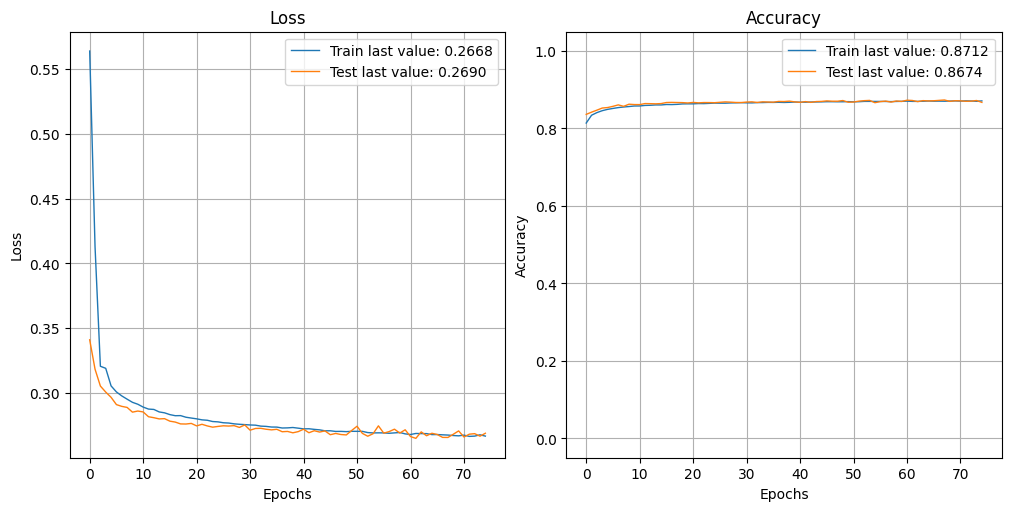

In [205]:
from plot_keras_history import show_history, plot_history
import matplotlib.pyplot as plt
plot_history(history)

In [206]:
prediction =model_conv1D .predict(X_trains)

13716/13716 [==============================] - 27s 2ms/step


In [46]:
t=[5.9312190000000005,0.0,3525.0,0.0,0.0,0.0,6.0,3845.0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1]
t = scaler.fit_transform(np.array(t).reshape(1, -1))
t=pd.DataFrame(t)
pred =model_conv1D .predict(t)

1/1 [==============================] - 0s 16ms/step


In [7]:
prediction1 =model_conv1D .predict(X_tests)
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
my_accuracy1=accuracy_score(y_test,prediction1.round())
recall1=recall_score(y_test,prediction1.round())
precision1=precision_score(y_test,prediction1.round())
f1_sc1=f1_score(y_test,prediction1.round())
print("Accuracy",my_accuracy1)
print("Recall",recall1)
print("precision",precision1)
print("F1_score",f1_sc1)
from sklearn.preprocessing import binarize
prediction1_binarized = binarize(prediction1.reshape(1, -1), threshold=0.5)[0]
print(prediction1_binarized)

3429/3429 [==============================] - 12s 3ms/step
Accuracy 0.8655912508544088
Recall 0.8763152823280015
precision 0.8451730418943534
F1_score 0.8604624758732922
[1. 1. 1. ... 1. 1. 1.]


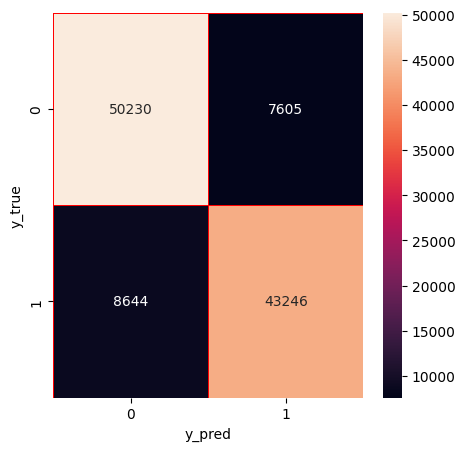

In [216]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import binarize
prediction1_binarized = binarize(prediction1.reshape(1, -1), threshold=0.5)[0]

cm= confusion_matrix(y_test, prediction1_binarized)
import seaborn as sns 
f, ax =plt.subplots(figsize = (5,5))

sns.heatmap(cm,annot = True, linewidths= 0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

3429/3429 [==============================] - 14s 4ms/step
Régression Logistique : ROC AUC=0.952


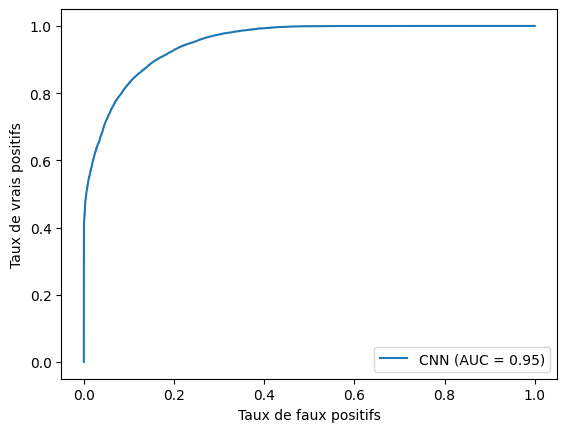

In [236]:
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
ns_probs = [0 for _ in range(len(y_test))]
lr_probs = model_conv1D.predict(X_tests)

# keep probabilities for the positive outcome only

# calculate scores

ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
# summarize scores

print('Régression Logistique : ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# plot the roc curve for the model
pyplot.plot(lr_fpr, lr_tpr,  label='CNN (AUC = {:.2f})'.format(lr_auc))
# axis labels
pyplot.xlabel('Taux de faux positifs')
pyplot.ylabel('Taux de vrais positifs')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()